In [74]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly, find_peaks
import neurokit2 as nk
import rsp.data_processing.signal_processing as signal_processing
from rsp.plotting import Rsp_Kit

import importlib
importlib.reload(signal_processing)
importlib.reload(Rsp_Kit)

<module 'rsp.plotting.Rsp_Kit' from 'C:\\Users\\thoma\\Code\\ResearchCode\\respiratory_pilot\\src\\rsp\\plotting\\Rsp_Kit.py'>

In [75]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [76]:
cagemate_4_7_h5_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
bully_4_7_h5_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\file_conversion\updated_meta_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"

cagemate_4_7_b_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\behavior_aim1\RI1_s4_7_p5_2_nRB3_HEEPS_good.csv"
bully_4_7_b_path = r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\Data\behavior_aim1\RI2_s4_7_p5_2_nRB3_HEEPS_good.csv"

In [77]:
cagemate_4_7_boris = pd.read_csv(cagemate_4_7_b_path)
bully_4_7_boris = pd.read_csv(bully_4_7_b_path)

### Filtering out social_agent so only subject behaviors plotted

In [78]:
# taking out all rows with subject=social_agent
cagemate_4_7_boris = cagemate_4_7_boris[cagemate_4_7_boris['Subject'] != 'social_agent']
bully_4_7_boris = bully_4_7_boris[bully_4_7_boris['Subject'] != 'social_agent']

In [79]:
cagemate_4_7_boris.head()

,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop
1,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,13.633,13.733,0.100,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,409,412.0,NaN,NaN,NaN,NaN
2,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,16.000,17.733,1.733,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,480,532.0,NaN,NaN,NaN,NaN
3,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,19.233,20.367,1.134,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,577,611.0,NaN,NaN,NaN,NaN
4,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,anogenital sniffing,Not defined,STATE,21.633,23.532,1.899,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,649,NaN,NaN,NaN,NaN,NaN
5,RI1_s4_7_p5_2_nRB3,2025-06-29 10:29:43.592,NaN,Media file,player #1:C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,0.0,505.966,627.8,30.0,subject,47.492,body sniffing,Not defined,STATE,23.533,24.099,0.566,C:/Users/thoma/Desktop/BorisVidsObservation/RI1_s4_7_p5_2_nRB3_20250621_150707.1.mp4,706,NaN,NaN,NaN,NaN,NaN


### Function to quickly get read and filter resp data and create Rsp_Kit object with behavior

In [80]:
def get_kit(h5_file, target_rate=100, behavior_data=None):
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
    except Exception as e:
        return {"file": os.path.basename(h5_file), "error": str(e)}

    try:
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except KeyError:
        return {"file": os.path.basename(h5_file), "error": "Missing 'duration_sec' metadata"}

    # Step 1: Pre-downsampling apply low-pass filter
    cutoff_hz = target_rate / 2
    nyquist = fs / 2
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Step 2: Downsample
    downsample_factor = int(fs // target_rate)
    downsampled_resp = resample_poly(filtered_resp, up=1, down=downsample_factor)
    duration_downsampled = len(downsampled_resp) / target_rate

    # Step 3: Apply neurokit2 Butterworth bandpass filter after downsampling
    rsp_cleaned = nk.signal_filter(
        downsampled_resp,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    return Rsp_Kit.Rsp_Kit(rsp_cleaned, fs=target_rate, n_samples=len(rsp_cleaned), behavior_data=behavior_data)


In [81]:
bully_4_7_kit = get_kit(bully_4_7_h5_path, target_rate=100, behavior_data=bully_4_7_boris) 
cagemate_4_7_kit = get_kit(cagemate_4_7_h5_path, target_rate=100, behavior_data=cagemate_4_7_boris)

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.
Overlaying behavior: facial sniffing


C:\Users\thoma\Code\ResearchCode\respiratory_pilot\src\rsp\plotting\Rsp_Kit.py:427: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.3)


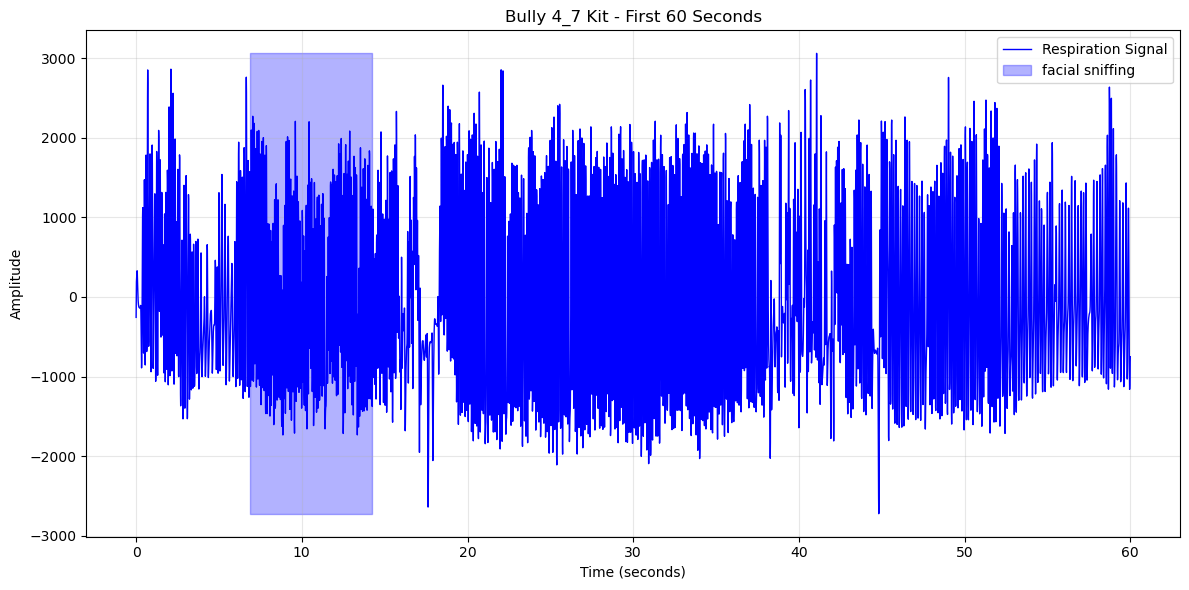

Index(['Timestamps', 'Respiration Value', 'Behavioral Event', 'Peaks'], dtype='object')
Behavioral data is present, overlaying behavior events.
Overlaying behavior: anogenital sniffing
Overlaying behavior: facial sniffing


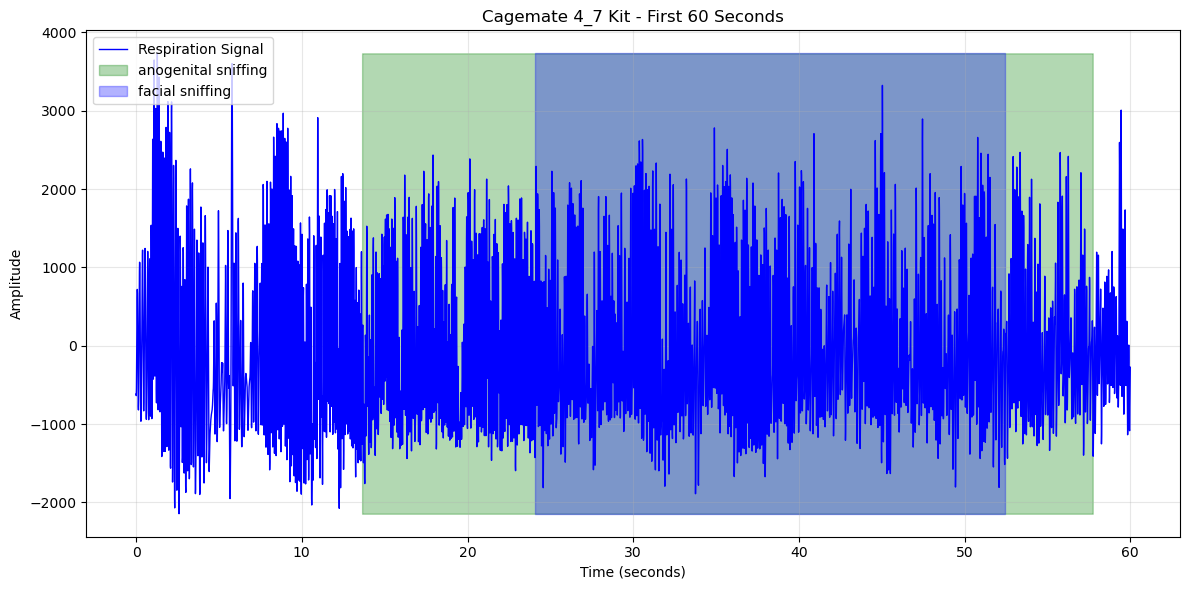

In [83]:
bully_4_7_kit.plot(duration=60, behavior_data=True, title="Bully 4_7 Kit")
cagemate_4_7_kit.plot(duration=60, behavior_data=True, title="Cagemate 4_7 Kit")